In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("../data/raw/data.csv")

print("Shape:", df.shape)
df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [4]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [5]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

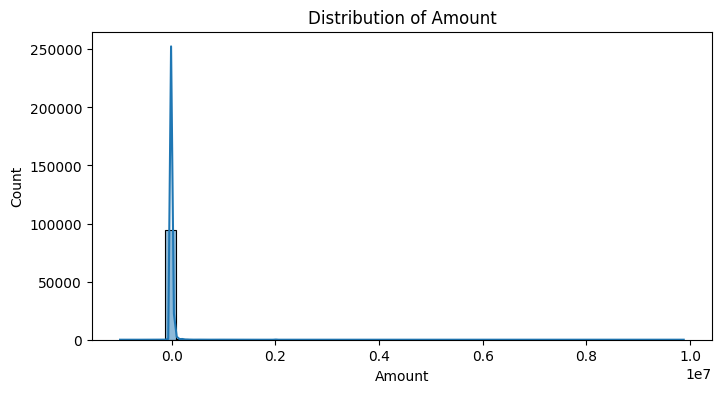

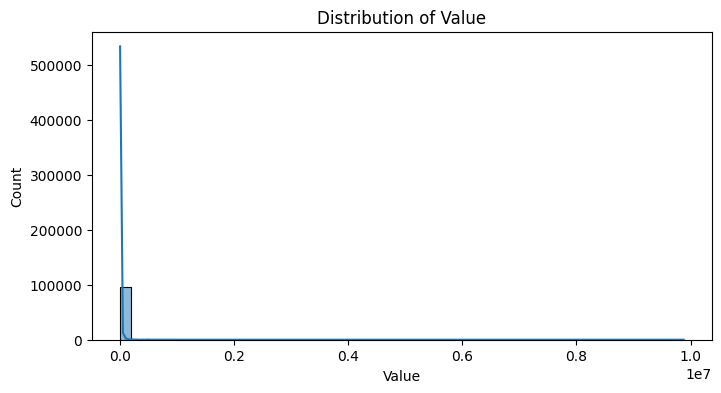

In [6]:
num_cols = ["Amount", "Value"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

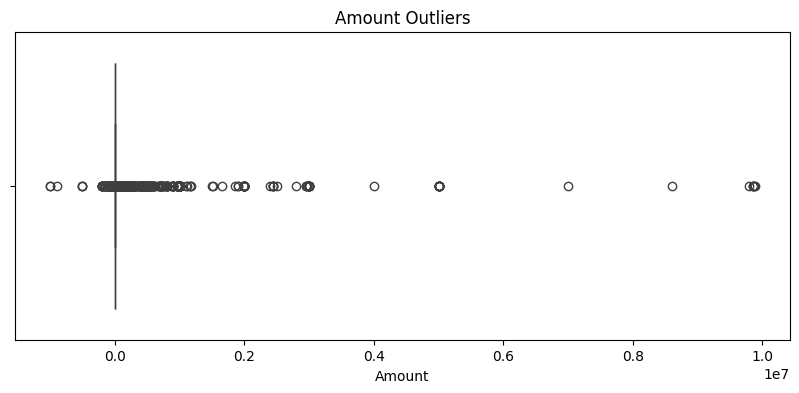

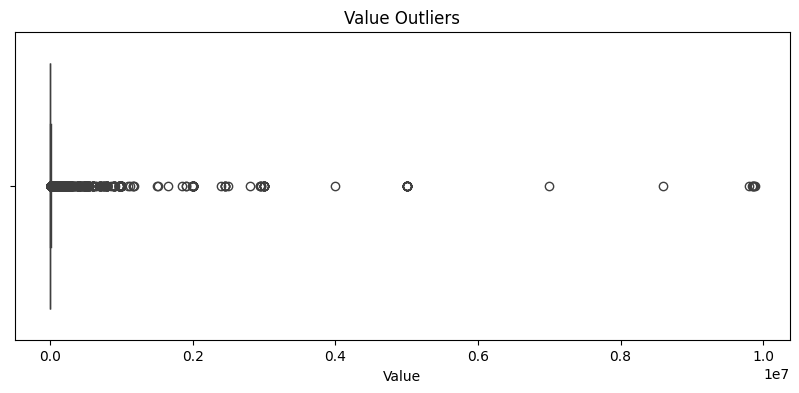

In [7]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Amount"])
plt.title("Amount Outliers")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Value"])
plt.title("Value Outliers")
plt.show()

In [8]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

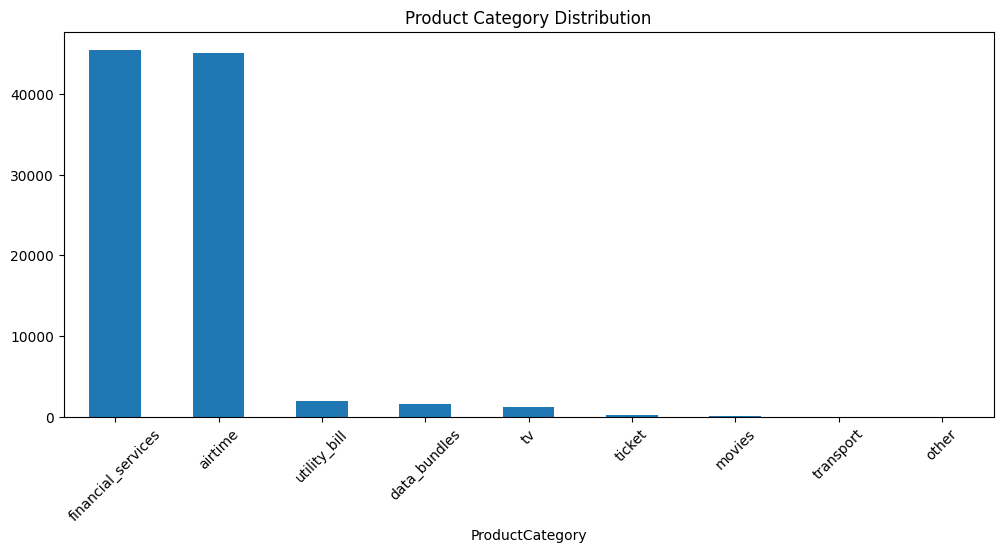

In [9]:
plt.figure(figsize=(12,5))
df["ProductCategory"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [10]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

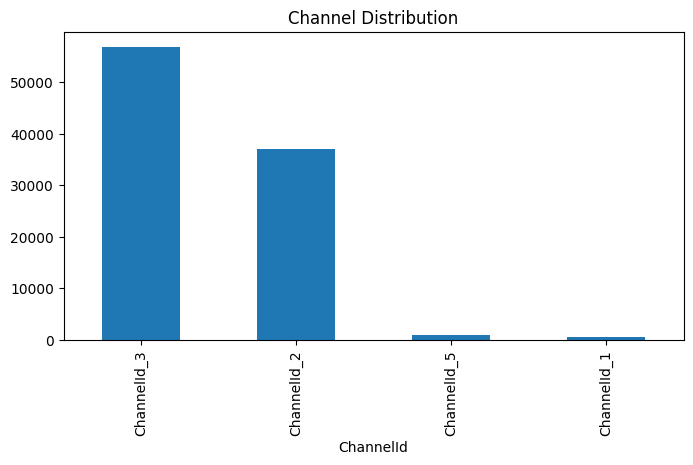

In [11]:
plt.figure(figsize=(8,4))
df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Channel Distribution")
plt.show()

In [12]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

In [13]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

# Key Insights from Exploratory Data Analysis

## Insight 1: Dataset Size and Structure

The dataset contains 95,662 transaction records and 16 features, providing a rich source of customer behavioral information for credit risk modeling. The data includes transaction details, customer identifiers, product information, and fraud indicators.

## Insight 2: No Missing Values

No missing values were found in any of the dataset columns. This improves data quality and reduces the need for extensive preprocessing or imputation techniques.

## Insight 3: Transaction Amounts are Highly Skewed

The Amount and Value variables exhibit strong positive skewness and contain numerous extreme outliers. While the median transaction amount is 1,000 UGX, the maximum transaction amount reaches 9.88 million UGX. Appropriate scaling and feature engineering techniques will therefore be required.

## Insight 4: Severe Class Imbalance in Fraud Labels

Fraudulent transactions represent approximately 0.20% of all observations. This indicates a highly imbalanced dataset, which should be considered when evaluating predictive models.

## Insight 5: Transactions are Concentrated in a Few Categories

Financial Services (45,405 transactions) and Airtime (45,027 transactions) account for the vast majority of transactions. Other categories such as Transport, Movies, and Other have very limited observations.

## Insight 6: Customer Activity is Dominated by Two Channels

Most transactions occur through ChannelId_3 (56,935 transactions) and ChannelId_2 (37,141 transactions), while the remaining channels contribute only a small proportion of overall activity. Transaction channel may therefore be an important predictive feature.


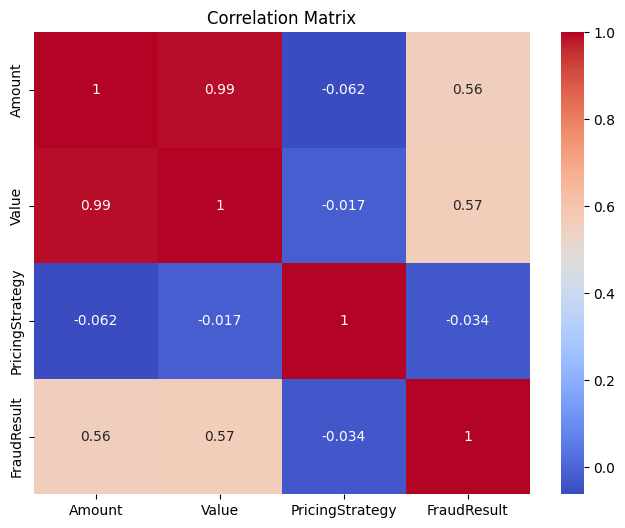

In [14]:
corr = df[["Amount","Value","PricingStrategy","FraudResult"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()